# Notebook For Figure 6

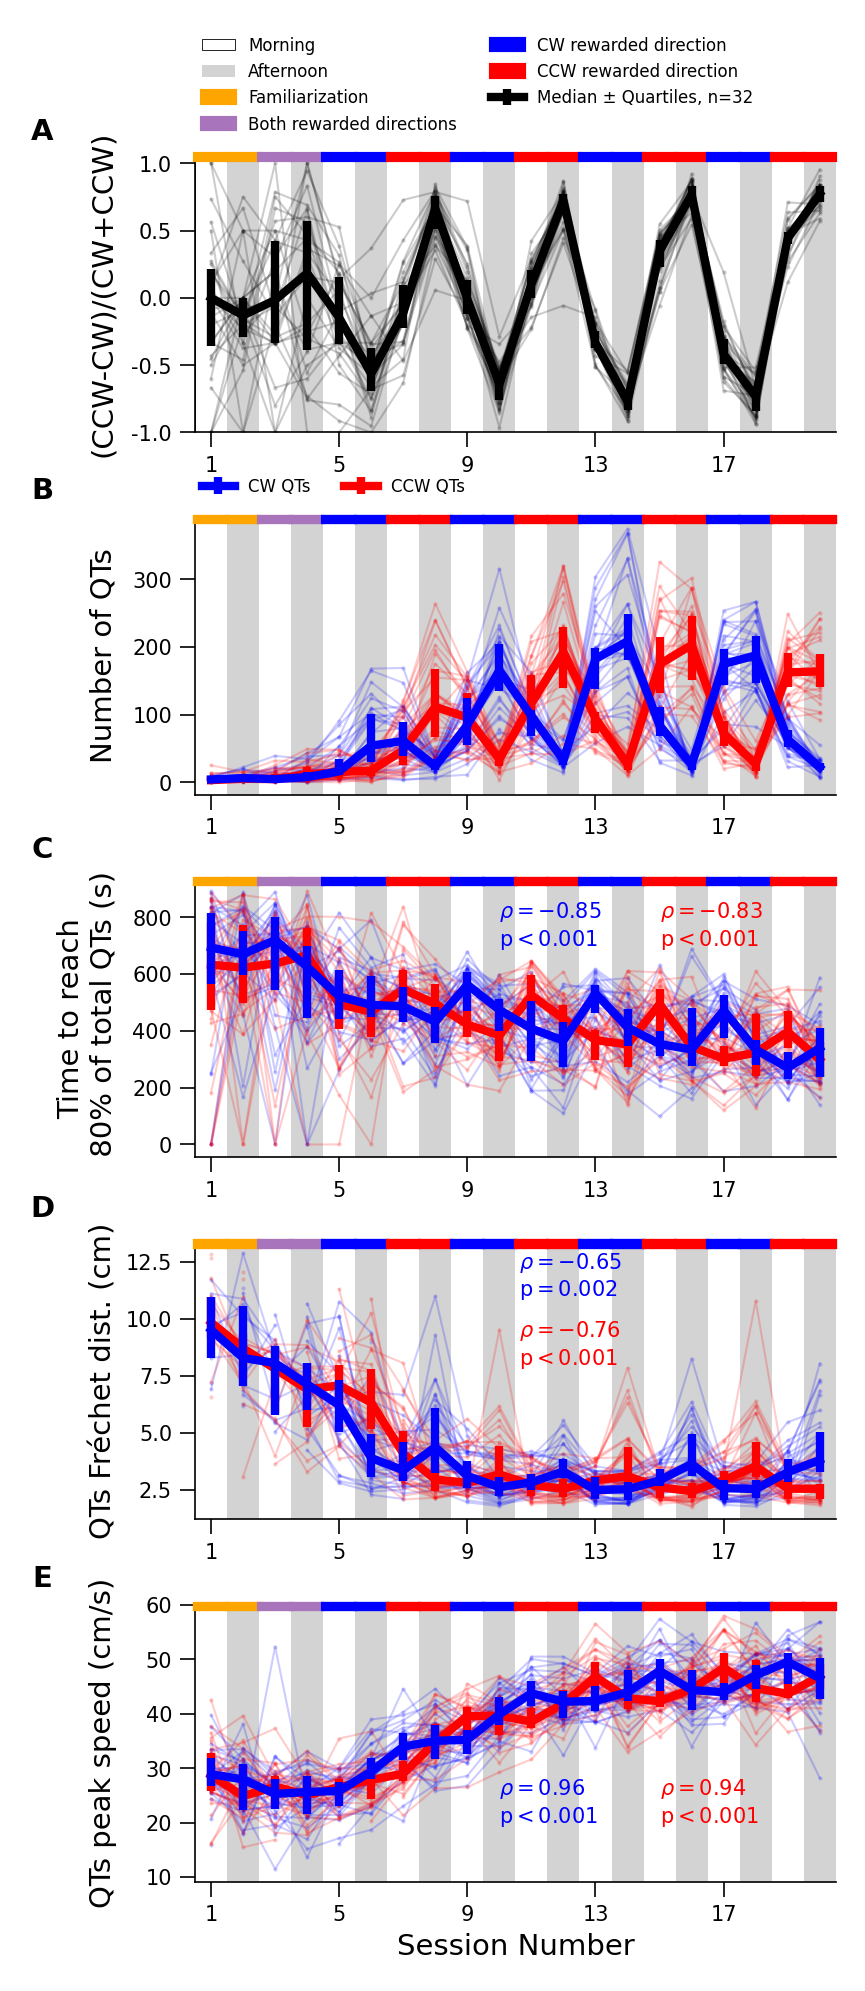

In [23]:
from IPython.display import display
from PIL import Image

# Load and display the image
img = Image.open("Figure08.png")
display(img)


# 1. Imports necessary libraries and functions

In [2]:
import os
from processing_TowerCoordinates import *
from processing_session_trajectory import *
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.gridspec import GridSpec
import numpy as np
import pickle
import similaritymeasures as sm
from bisect import bisect
from scipy.stats import spearmanr

plt.style.use('paper.mplstyle')


In [3]:
plotintermediatesteps = False

# 2. Select mice to analyse
### Define the data_folder where your MOU* folders are, generate a list of MOU* folders and for each mouse generate a list of all the sessions recorded

In [4]:
# defining data folder path and mice list

# path_to_data_folder is the path of the folder where you store the folders of your different mice.

# path_to_data_folder='/home/david/MyLocalData/4TowersTask_MethodPaper/Group2Data'
# path_to_data_folder = '/Users/davidrobbe/Documents/Science/Data/ForagingMice/AurelienData/'
path_to_data_folder='/LocalData/ForagingMice/4TowersTaskMethodPaper_Data/Group2Data/'
# path_to_data_folder='/home/tom/Thèse/Data/ForagingMice/4TowerTaskMethodPaper/Group2Data/'

# Analysing the entire group of mice
mice_to_analyse = ['MOU3974','MOU3975', 'MOU3987', 'MOU3988', 'MOU3991', 'MOU3992', 'MOU4551', 'MOU4552', 'MOU4560', 'MOU4561', 'MOU4562',
                   'MOU4563', 'MOU4623', 'MOU4964', 'MOU4965', 'MOU4986', 'MOU4987', 'MOU4988', 'MOU4993', 'MOU5007', 'MOU5008','MOU5130',
                   'MOU5131', 'MOU5136', 'MOU5140', 'MOU5142', 'MOU5143', 'MOU5144', 'MOU5145', 'MOU5148', 'MOU5149', 'MOU5158']
#mice_to_analyse = ['MOU3974','MOU3975', 'MOU3987', 'MOU3988', 'MOU3991', 'MOU3992', 'MOU4551', 'MOU4552', 'MOU4560', 'MOU4561', 'MOU4562','MOU4563', 'MOU4623']

# Verify that all folders in mice_to_analyse are present in path_to_data_folder
missing_folders = [mouse for mouse in mice_to_analyse if not os.path.isdir(os.path.join(path_to_data_folder, mouse))]

if missing_folders:
    print("Missing mice folders:", missing_folders)
else:
    print("All mice folders are present in data folder.")

# Print the number of mice, the list of mice
print(f' {len(mice_to_analyse)} {"mice" if len(mice_to_analyse) > 1 else "mouse"} will be analysed\n')

# Select the number of sessions that will be analysed for each mice knowing the analysis starts with the first session (familiarisation)
# The last sessions will be analysed from index first_and_last_session_indexes[0] (included) to first_and_last_session_indexes[1] (excluded). 
first_and_last_session_indexes = [0,20]
# Select the number of sessions that will be in statistics
first_and_last_session_indexes_stats = [1,20]
# Setting the seed for random processes used in statistics
seed = 27
np.random.seed(seed)

All mice folders are present in data folder.
 32 mice will be analysed



In [5]:
# Set the limits of the x-axis on the statistics plots
xlim_stats = [first_and_last_session_indexes[0]+0.5,first_and_last_session_indexes[1]+0.5]


The rewarding direction alternation (every day with 2 sessions per day) starts on session 5. In this session, some mice where rewarded in CW, and others in CCW. Mice that were rewarded in CCW were reversed in CW. This results in having all the mice treated as if they had the same rewarding direction.

# 3. Definition of functions

### General functions

In [6]:
def cm2inch(value):

    """
    Converts centimeters to inches for figure size.

    Arguments:
        value (float): value to convert in cm 

    """

    return value/2.54

def filter_qts(qts):

    """
    Filter out QTs with length above threshold and during which more than 1 switch occured.

    Arguments:
        qts (list): list of QTs (in the original format from the pickle)

    return:
        (list): list of filtered QTs
    """

    filtered_qts = []
    
    for qt in qts:

        # Skip current QT if there is more than 1 switches
        if qt[3]['num_trapezeswitch']!=1:
            
            continue
        
        # Skip current QT if it is longer than a threshold length (30 cm)
        if qt[4]['epoch_distance']>30:

            continue

        # Keep current QT if it did not check the removal conditions
        filtered_qts.append(qt)

    return filtered_qts

def count_qts(qts):

    total_qts = len(qts)
    cw_qts = 0
    rewarded_qts = 0

    for qt in qts:

        if qt[3]['direction']=='CW':

            cw_qts += 1

        if qt[3]['Rewarded']:

            rewarded_qts += 1

    return total_qts, cw_qts, rewarded_qts

def finding_mouse_rewarded_direction(folder_path_mouse_to_process, session_index, start_session_index=0):
    
    """
    Determines the rewarded direction for the last session of a given mouse.
    In the protocol this notebook is used for, the rewarded direction of the 
    last session is the same as in all the sessions where rewarding is allowed. 
    
    Arguments:
        folder_path_mouse_to_process (str): Path to the folder containing mouse sessions folders.
        session_index (int): Index of the session that will be used to define the rewarded direction
        start_session_index (int, optional): index of the first session in the list of sessions to analyse. 
                                   If different from 0, the session index should refer to 
                                   the index of the session in the sub-list of session to process, not the total list 

    Returns:
        str: 'CW' (Clockwise) if the rewarded direction is 270 degrees,
             'CCW' (Counterclockwise) if the rewarded direction is 90 degrees,
             numpy.nan if reward delivery is not allowed 
             None if an error occurs.
    """
    
    # Get all session folders that start with 'MOU' and sort them
    sessions_to_process = sorted([name for name in os.listdir(folder_path_mouse_to_process)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
                                  and name.startswith('MOU')])

    sessions_to_process = sessions_to_process[start_session_index:]

    # Load data from the last session
    session_traj_df, session_turns_df, session_param_df = load_data(folder_path_mouse_to_process, sessions_to_process[start_session_index+session_index])

    # Extract rewarded direction in degrees
    rewarded_direction_degrees = session_param_df["potentialRewardedDirections"][0]

    # Check if reward delivery is allowed
    if session_param_df["allowRewardDelivery"][0]:

        # Determine the rewarded direction based on the extracted value
        if rewarded_direction_degrees == '[270]':
            rewarded_direction = 'CW'  # Clockwise

        elif rewarded_direction_degrees == '[90]':
            rewarded_direction = 'CCW'  # Counterclockwise
            
        elif rewarded_direction_degrees == '[90, 270]':
            rewarded_direction = 'both'  # Both directions

        else:
            print('ERROR: Unexpected unique rewarded direction value:', rewarded_direction_degrees)
            return None  # Explicitly return None to indicate failure
    
    else:

        # Rewarded direction is set to X if reward delivery os not allowed
        rewarded_direction = 'X'

    return rewarded_direction

def plot_learning_curve_alt_direction(mouse_metric_persession, ax, mice_list=None, start_session_index=0, mice_to_highlight=[], mice_to_highlight_labels=[None,None],
                                      show_individual_mice=True, median_color='black', individual_color=None, show_xlabel=True, ylabel='', main_line_label=None,
                                      tick_interval=1, index_offset=0, xlim=[None,None], ylim=None, show_background_legend=False, show_legend=True):
    
    """
    Plots a given metric across sessions for multiple mice (also called a learning curves). Each session is color coded differently depending on
    it rewarding regime, and whether it happened it the morning or afternoon.

    Arguments:
        mouse_metric_persession (dict): Dictionary where keys are mouse IDs and values are lists of (session_index, value) lists.
        ax (matplotlib.axes.Axes): Axes object for plotting.
        mice_list (list, optional): List of mice to include in the plot. Defaults to all mice in the mouse_metric_persession.
        start_session_index (int, optional): index of the first session in the list of sessions to analyse. 
                                   If different from 0, the session index should refer to 
                                   the index of the session in the sub-list of session to process, not the total list
        mice_to_highlight (list, optional): List of up to two mice IDs to highlight with distinct colors.
        mice_to_highlight_labels (list, optional): List of the label of the mice to highlight.
        show_individual_mice (bool, optional): If true, plot a line for each individual mouse.
        session_limit (tuple, optional): Inrerval of session indexes to plot. Defaults to [None,None] (plot all sessions).
        show_xlabel (bool, optional): Whether to display the x-axis label. Defaults to True.
        ylabel (str, optional): Label for the y-axis.
        main_line_label (str, optional): Label of the median and quartiles range.
        tick_interval (int, optional): Interval for x-axis tick marks. Defaults to 1.
        index_offset (int, optional): Offset to apply to the numbers in the x axis. Use it if you want to the first sessions to be named '1'.
        xlim (tuple, optional): Tuple specifying x-axis limits. Defaults to None.
        ylim (tuple, optional): Tuple specifying y-axis limits. Defaults to None.
        show_background_legend (bool, optional): Whether to show the legend of the session color codes. Defaults to False.
        show_legend (bool, optional): Whether to show the legend. Defaults to True.
    """

    # If no mice are specified, use all available mice
    if mice_list is None:
        mice_list = list(mouse_metric_persession.keys())

    # If we don't provide an individual color, we keep median_color for individual values
    if individual_color is None:
        individual_color = median_color

    all_session_indexes = set()  # Track all session indices across selected mice
    values_per_session = {}  # Store values for each session across mice

    # Loop through each mouse and gather session data
    for mouse in mice_list:
        if mouse not in mouse_metric_persession:
            print(f"Mouse {mouse} not found in data. Skipping.")
            continue    

        # Selecting the sub-list of sessions to analyse
        sessions = mouse_metric_persession[mouse]

        # Extract session indices and corresponding values
        session_indexes = [session[0] for session in sessions]
        values = [session[1] for session in sessions]

        # Plot learning curves for each mouse if show_individual_mice is True
        if show_individual_mice:
    
            if mouse in mice_to_highlight: # Plot the values in opac dark orange or green if the current mouse is in mice_to_highlight
                highlight_colors = ["darkorange", "green"]
                color_idx = mice_to_highlight.index(mouse) if mice_to_highlight.index(mouse) < len(highlight_colors) else 0
                ax.plot(session_indexes, values, color=highlight_colors[color_idx], marker='o', linewidth=0.5, 
                        markersize=1, label=mice_to_highlight_labels[mice_to_highlight.index(mouse)], zorder=100*len(median_color))
            else:
                ax.plot(session_indexes, values, marker='o', linewidth=0.5, markersize=1, alpha=0.2, markeredgewidth=0.0, color=individual_color)

        # Update session index tracking
        all_session_indexes.update(session_indexes)
        for session, value in sessions:
            if session not in values_per_session:
                values_per_session[session] = []
            values_per_session[session].append(value)

    # Convert session indices to a sorted list
    sorted_sessions = sorted(all_session_indexes)

    # Compute median and 25th-75th percentile range for each session
    median_values = []
    lower_quartile = []
    upper_quartile = []

    for session in sorted_sessions:
        session_values = values_per_session[session]
        median_values.append(np.nanmedian(session_values))
        lower_quartile.append(np.nanpercentile(session_values, 25))
        upper_quartile.append(np.nanpercentile(session_values, 75))

    median_values = np.array(median_values)
    lower_quartile = np.array(lower_quartile)
    upper_quartile = np.array(upper_quartile)

    # Find the first mouse of the sample. It will be used to determine the rewarded direction of the session
    folder_path_first_mouse = os.path.join(path_to_data_folder,list(mouse_metric_persession.keys())[0])

    # Initialize a set to contain colors that have already been shown in the legend
    used_colors = set([])

    # Iterate on the index of sessions
    for session_index in range(len(sorted_sessions)):
            
            # Fint the rewarded direction of the session
            rewarded_direction = finding_mouse_rewarded_direction(folder_path_first_mouse, session_index, start_session_index)

            # Checks if rewarding was available
            rewarding = rewarded_direction != 'X'

            # If there is no rewarding, color code the session in orange
            if not(rewarding):
                band_color = "orange"
                direction_label = "Familiarization" if show_background_legend else None

            # If both directions are rewarded, color code the session in purple
            elif rewarded_direction == "both":
                band_color = "#a875bc"
                direction_label = "Both rewarded directions" if show_background_legend else None

            # If the day is odd, color code the sessions in this day in blue
            elif session_index%4 < 2:
                band_color = "blue"
                direction_label = "CW rewarded direction" if show_background_legend else None

            # Else, color code them in red
            else:
                band_color = "red"
                direction_label = "CCW rewarded direction" if show_background_legend else None

            ax.axvspan(session_index+1 - 0.49, session_index+1 + 0.49, ymin=0.979, ymax=0.998,
                       color=band_color, zorder=3, clip_on=False, label = direction_label if not(band_color in used_colors) else None )

            # Add the color code to the used_colors set so that it will not appear several times on the legend
            used_colors.add(band_color)

            # Color the session in clear grey if it happened in afternoon, and light grey if it happened on morning
            if session_index % 2 != 0:  # Odd (PM sessions)
                
                vspan_color = "lightgrey"
                vspan_label = "Afternoon" if show_background_legend else None

                ax.axvspan(
                    session_index + 0.5, session_index + 1.5,
                    color="lightgrey", zorder=0, label = vspan_label if not(vspan_color in used_colors) else None,
                    lw=0
                )
                
            else:
                
                vspan_color = "white"
                vspan_label = "Morning" if show_background_legend else None

                ax.axvspan(
                    session_index + 0.5, session_index + 1.5,
                    color=vspan_color, zorder=0, label = vspan_label if not(vspan_color in used_colors) else None,
                    lw=0
                )

            used_colors.add(vspan_color)

    # If the median and quartiles range don't have a label, give them a default label.
    if not main_line_label:

        main_line_label = f'Median \u00B1 Quartiles, n={len(mice_list)}'

    # Plot median learning curve with shaded 25th-75th percentile range
    ax.errorbar(np.array(sorted_sessions)+index_offset, median_values, yerr=[median_values-lower_quartile, upper_quartile-median_values], alpha=1,
                color=median_color, linewidth = 2, label=main_line_label, zorder=50*len(median_color))

    # Set axis labels and formatting
    if show_xlabel:
        ax.set_xlabel('Session Number', fontsize=7)
    
    ax.set_ylabel(ylabel, fontsize=7)

    # Ensure x-axis labels are integers
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    # Set x-ticks at specified intervals
    if all_session_indexes:
        max_index = max(all_session_indexes)
        ax.set_xticks(range(1, max_index + 1, tick_interval))

    # Apply x and y axis limits if provided
    if xlim is not None:
        ax.set_xlim(xlim)
    
    if ylim is not None:
        ax.set_ylim(ylim)

    # Show legend if required
    if show_legend:

        if show_background_legend:
            # Organising background legend so that the Morning/Afternoon are shown first
            handles, labels = plt.gca().get_legend_handles_labels()
            current_order = list(range(len(handles)))
            target_order = current_order[1:3] + [current_order[0]] + current_order[3:]

            # Add a black outline only to the "Morning" patch
            for h, l in zip(handles, labels):
                if l == "Morning" and isinstance(h, plt.Rectangle):
                    h.set_edgecolor("black")
                    h.set_linewidth(0.2)

            ax.legend(
                [handles[idx] for idx in target_order],
                [labels[idx] for idx in target_order],
                frameon=False, fontsize=4, loc=(0,1.05), ncol=2
            )

        else:
            ax.legend(frameon=False, fontsize=4, loc=(0,1.05), ncol=2)

def shuffled_spearman_test(mouse_values_persession, shuffle_number, hypothesis, illustration_mouse_name = None, first_and_last_session_indexes=[None,None]):
    
    """
    Compute the Spearman correlation coefficient of input session-wise data then compare it to a null distribution computed by shuffling
    the input data several times

    Arguments:
        mouse_values_persession (dict): Dictionary with session numbers as keys and the corresponding values as entries
        shuffle_number (int): Number of time the data will be shuffled and the corresponding correlation coefficient computed 
        hypothesis (string): Hypothesis tested, whether the values sequence is increasing or decreasing across sessions
        illustration_mouse_name (list, optional): List of mice from mouse_values_persession to use
        first_and_last_session_indexes (list, optional): List containing indexes of first and last session to plot
    
    Return:
        (list): list containing the Spearman correlation coefficient of the unshuffled data and the p-value associaed to the test
    """

    # Selecting mice to analyse
    if illustration_mouse_name is None:
        illustration_mouse_name = list(mouse_values_persession.keys())

    ### Compute the Spearman correlation coefficient distribution by shuffling data ###

    # Initialize the list where the Spearman correlation coefficients from shuffled data will be stored. 
    # This will be the null distribution of Spearman correlation coefficient
    spearman_rho_list = []
    
    # Shuffle the data shuffle_number times
    for _ in range(shuffle_number):

        # Initialize the list that will contain shuffled data
        shuffled_values_list = []
        
        # Iterate on every mice
        for mouse in illustration_mouse_name:

            # Checking if the current mouse has no value to plot
            if mouse not in mouse_values_persession:
                print(f"Mouse {mouse} not found in data. Skipping.")
                continue    

            # Selecting sessions under the limit
            sessions = copy.deepcopy(mouse_values_persession[mouse][first_and_last_session_indexes[0]:first_and_last_session_indexes[1]])

            # Extract sessions number
            session_indices = [session[0] for session in sessions]
            # Extract and shuffle values 
            shuffled_values = np.random.choice([session[1] for session in sessions], size=len(sessions), replace=False)
            # Store the shuffled values
            shuffled_values_list.append(shuffled_values)

        # Compute the median over all the mice
        median_values = np.nanmedian(shuffled_values_list,axis=0)
        # Compute the Spearman correlation coefficient of the median
        spearman_result = spearmanr(session_indices, median_values)
        # Store the coefficient
        spearman_rho_list.append(spearman_result[0])
    
    ### Compute the Spearman correlation coefficient of unshuffled data ###

    values_list = []

    for mouse in illustration_mouse_name:

        # Checking if the current mouse has no value to plot
        if mouse not in mouse_values_persession:
            print(f"Mouse {mouse} not found in data. Skipping.")
            continue    

        # Selecting sessions under the limit
        sessions = copy.deepcopy(mouse_values_persession[mouse][first_and_last_session_indexes[0]:first_and_last_session_indexes[1]])

        # Extract sessions number
        session_indices = [session[0] for session in sessions]

        # Extract values
        values = [session[1] for session in sessions]
        
        # Store the value
        values_list.append(values)

    # Compute the median over all the mice
    actual_median_values = np.nanmedian(values_list,axis=0)

    # Compute the Spearman correlation coefficient of the median
    actual_spearman_result = spearmanr(session_indices,actual_median_values, nan_policy='omit')
    actual_rho = actual_spearman_result[0]

    # Compute the p-value corresponding to the tested hypothesis
    if hypothesis=="increasing":
        # Computing the the proportion of the null distribution above the correlation coefficient of unshuffled data. This is the p-value
        p_value = len(spearman_rho_list[bisect(np.sort(spearman_rho_list), actual_rho):])/len(spearman_rho_list)
    elif hypothesis=="decreasing":
        # Computing the the proportion of the null distribution below the correlation coefficient of unshuffled data. This is the p-value
        p_value = len(spearman_rho_list[:bisect(np.sort(spearman_rho_list), actual_rho)])/len(spearman_rho_list)
    else:
        # Raise an error if no valid hypothesis was made
        print("ERROR : Invalid hypothesis. Please specify increasing or decreasing")
        return

    return actual_rho, p_value

def plot_shuffled_spearman_test_res(ax, text_loc, mouse_values_persession, n_shuffles, hypothesis, color='black', illustration_mouse_name=None, first_and_last_session_indexes=[1,None]):

    """
    Plots the result of shuffled_spearman_test as a text on a figure.

    Arguments:
        ax (matplotlib.axes.Axes): Axes object for plotting
        text_loc (list): coordinate of the text (in data units)
        mouse_values_persession (dict): Dictionary with session numbers as keys and the corresponding values as entries
        shuffle_number (int): Number of time the data will be shuffled and the corresponding correlation coefficient computed 
        hypothesis (string): Hypothesis tested, whether the values sequence is increasing or decreasing across sessions
        color (str): Color of the text
        illustration_mouse_name (list, optional): List of mice from mouse_values_persession to use
        first_and_last_session_indexes (list, optional): List containing indexes of first and last session to plot
    
    """

    test_res = shuffled_spearman_test(mouse_values_persession, n_shuffles, hypothesis, illustration_mouse_name=illustration_mouse_name, first_and_last_session_indexes=first_and_last_session_indexes)    

    if test_res[1]==0:
        
        ax.text(text_loc[0],text_loc[1],rf'$\rho = {round(test_res[0],2)}$' + '\n' + rf'p$ < 0.001$', fontsize=5, color=color) 

    else:

        ax.text(text_loc[0],text_loc[1],rf'$\rho = {round(test_res[0],2)}$' + '\n' + rf'p$ = {round(test_res[1],3)}$', fontsize=5, color=color)

# 4. Panel A, B, E

### This cell computes and store metrics related to the number of QTs that will be plotted for each mouse across sessions. Those metrics are:
- The number of turns in CW and CCW direction;
- The ratio of the difference of the number of CCW and CW turns with respect to the total number of turns.
    
$ \frac{N_{CCW}-N_{CW}}{N_{CCW}+N_{CW}} $
 
- The time that the mouse took to perform 80% of the total number of turns in CW and CCW direction. 

### The next two functions are used to:
- Find the times at which QTs occured.
- Find the time at which the number of QTs becomes higher than a given threshold.

In [7]:
def cumulated_turns_time_profile(folder_path_mouse_to_process, session_to_process, rewarded_direction):
    """
    Computes the cumulative number of runs around a tower at each time a new run around a tower occurs, for a given session and a given mouse.

    Arguments:
        folder_path_mouse_to_process (str): Path to the folder containing mouse session data.
        session_to_process (str): Name of the session to be processed.
        reference_session_index (int): Index of the session that will be used to define the rewarded direction
        
    Returns:
        tuple: Two lists containing:
            - (good_turns_time, cumulated_good_turns): Sorted times and cumulative counts for turns in rewarding direction.
            - (bad_turns_time, cumulated_bad_turns): Sorted times and cumulative counts for turns in non-rewarded direction.
    """

    # Construct the path to the session pickle file
    output_pickle_filename = f"{session_to_process}_basic_processing_output.pickle"
    output_pickle_filepath = os.path.join(folder_path_mouse_to_process, session_to_process, output_pickle_filename)

    # Load session data from the pickle file
    with open(output_pickle_filepath, 'rb') as file:
        session_data = pickle.load(file)

    # Deep copy the list of turn epochs
    runs_around_tower = filter_qts(copy.deepcopy(session_data['all_epochs']['run_around_tower']))

    # Initialize lists to store filtered turns
    time_of_runsaroundtower_CW = []
    time_of_runsaroundtower_CCW = []

    # Iterate through each recorded turn around the tower
    for run_around_tower in runs_around_tower:

        # Categorize turns based on direction
        if run_around_tower[3]['direction'] == 'CW':
            time_of_runsaroundtower_CW.append(run_around_tower[4]['epoch_time'])
        elif run_around_tower[3]['direction'] == 'CCW':
            time_of_runsaroundtower_CCW.append(run_around_tower[4]['epoch_time'])

    # Sort the turn times for cumulative calculations
    CW_times_sorted = np.sort(time_of_runsaroundtower_CW)
    CCW_times_sorted = np.sort(time_of_runsaroundtower_CCW)

    # Compute cumulative counts for each direction
    CW_cumulative = np.arange(1, len(CW_times_sorted) + 1)
    CCW_cumulative = np.arange(1, len(CCW_times_sorted) + 1)
    
    # Assign good and bad turns based on the rewarded direction
    if rewarded_direction == 'CW':
        good_turns_time = CW_times_sorted
        bad_turns_time = CCW_times_sorted
        cumulated_good_turns = CW_cumulative
        cumulated_bad_turns = CCW_cumulative

    elif rewarded_direction == 'CCW':
        good_turns_time = CCW_times_sorted
        bad_turns_time = CW_times_sorted
        cumulated_good_turns = CCW_cumulative
        cumulated_bad_turns = CW_cumulative

    elif rewarded_direction == 'X':

        good_turns_time = np.ones(len(CCW_times_sorted))*np.nan
        bad_turns_time = np.ones(len(CW_times_sorted))*np.nan
        cumulated_good_turns = np.ones(len(CCW_cumulative))*np.nan
        cumulated_bad_turns = np.ones(len(CW_cumulative))*np.nan

    else:
        print('ERROR: Unexpected rewarded direction value')
        return None  # Explicitly return None to indicate an error

    return [good_turns_time, cumulated_good_turns], [bad_turns_time, cumulated_bad_turns]


In [8]:
def accumulation_threshold(cummulated_events_time, threshold_fraction=0.8):

    """
    Compute the first time point at which the cummulated number of event in cummulated_events_time
    is above a threshold, that is a fraction (80% by default) of the total number of events.
    
    Arguments:
        cummulated_events_time (list): list of time at which one event occurs.
        threshold_fraction (float, optional): fraction of the total number of event that will used as threshold. 

    Returns:
        float: first value in cummulated_events_time that is above the
        
    """

    # Compute the total number of events
    total_events = len(cummulated_events_time)

    # If there is no event, the time when the fraction of events crosses the threshold is 0.
    if total_events==0:

        return 0

    # Initialise index of the first event
    i = 0

    # Compute the fraction of cummulated events
    fraction_of_events = (i+1)/total_events if total_events!=0 else 0

    # Iterate while the fraction of cummulated events is lower than the threshold fraction 
    while fraction_of_events<threshold_fraction:

        # Increase the index
        i = i + 1
        # Update the fraction of cummulated events at the new index
        fraction_of_events = (i+1)/total_events

    res = cummulated_events_time[i] if total_events!=0 else 0

    # Return the first time in cummulated_events_time at which the fraction of cummulated events is higher than threshold_fraction.  
    return res


In [9]:
def shuffled_distribution_test(mouse_values_persession, shuffle_number, illustration_mouse_name = None, first_and_last_session_indexes=[None,None]):
    
    """
    Compute the Spearman correlation coefficient of input session-wise data then compare it to a null distribution computed by shuffling
    the input data several times

    Arguments:
        mouse_values_persession (dict): Dictionary with session numbers as keys and the corresponding values as entries
        shuffle_number (int): Number of time the data will be shuffled and the corresponding correlation coefficient computed 
        hypothesis (string): Hypothesis tested, whether the values sequence is increasing or decreasing across sessions
        illustration_mouse_name (list, optional): List of mice from mouse_values_persession to use
        first_and_last_session_indexes (list, optional): List containing indexes of first and last session to plot
    
    Return:
        (list): list containing the Spearman correlation coefficient of the unshuffled data and the p-value associaed to the test
    """

    # Selecting mice to analyse
    if illustration_mouse_name is None:
        illustration_mouse_name = list(mouse_values_persession.keys())

    ### Compute the Spearman correlation coefficient distribution by shuffling data ###

    # Initialize the list where the median sequences will be stored. 
    # This will be the null distribution of median points
    suffled_median_list = []
    
    # Shuffle the data shuffle_number times
    for _ in range(shuffle_number):

        # Initialize the list that will contain shuffled data
        shuffled_values_list = []
        
        # Iterate on every mice
        for mouse in illustration_mouse_name:

            # Checking if the current mouse has no value to plot
            if mouse not in mouse_values_persession:
                print(f"Mouse {mouse} not found in data. Skipping.")
                continue    

            sessions = copy.deepcopy(mouse_values_persession[mouse][first_and_last_session_indexes[0]:first_and_last_session_indexes[1]])

            # Extract sessions number
            sessions_number = [session[0] for session in sessions]
            # Extract and shuffle values 
            shuffled_values = np.random.choice([session[1] for session in sessions], size=len(sessions), replace=False)
            # Store the shuffled values
            shuffled_values_list.append(shuffled_values)

        # Compute the median over all the mice
        median_values = np.nanmedian(shuffled_values_list,axis=0)
        
        # Store the median
        suffled_median_list.append(median_values)
    
    upper_bounds = np.percentile(suffled_median_list, 97.5, axis=0)
    lower_bounds = np.percentile(suffled_median_list, 2.5, axis=0)
    total_lower_bound = np.percentile(suffled_median_list, 2.5)
    total_upper_bound = np.percentile(suffled_median_list, 97.5)


    ### Compute the Spearman correlation coefficient of unshuffled data ###

    values_list = []

    for mouse in illustration_mouse_name:

        # Checking if the current mouse has no value to plot
        if mouse not in mouse_values_persession:
            print(f"Mouse {mouse} not found in data. Skipping.")
            continue    

        # Selecting sessions under the limit
        sessions = copy.deepcopy(mouse_values_persession[mouse][first_and_last_session_indexes[0]:first_and_last_session_indexes[1]])

        # Extract sessions number
        sessions_number = [session[0] for session in sessions]

        # Extract values
        values = [session[1] for session in sessions]
        
        # Store the value
        values_list.append(values)

    # Compute the median over all the mice
    actual_median_values = np.nanmedian(values_list,axis=0)

    # Test whether the actual median sequence is out of the 95% intervall of the null distribution at every session
    significance_sequence = np.where(np.logical_or(actual_median_values<total_lower_bound,actual_median_values>total_upper_bound),actual_median_values,np.nan)
    
    return significance_sequence, sessions_number, upper_bounds, lower_bounds, total_upper_bound, total_lower_bound

def plot_shuffled_distribution_test_res(ax, mouse_values_persession, n_shuffles, pulled_interval=True, illustration_mouse_name=None, first_and_last_session_indexes=[1,None]):

    """
    Plots the result of shuffled_spearman_test as a text on a figure.

    Arguments:
        ax (matplotlib.axes.Axes): Axes object for plotting
        text_loc (list): coordinate of the text (in data units)
        mouse_values_persession (dict): Dictionary with session numbers as keys and the corresponding values as entries
        shuffle_number (int): Number of time the data will be shuffled and the corresponding correlation coefficient computed 
        hypothesis (string): Hypothesis tested, whether the values sequence is increasing or decreasing across sessions
        color (str): Color of the text
        illustration_mouse_name (list, optional): List of mice from mouse_values_persession to use
        first_and_last_session_indexes (list, optional): List containing indexes of first and last session to plot
    
    """

    significance_sequence, sessions_number, upper_bounds, lower_bounds, total_upper_bound, total_lower_bound = shuffled_distribution_test(mouse_values_persession, n_shuffles, illustration_mouse_name = illustration_mouse_name, first_and_last_session_indexes=first_and_last_session_indexes)
    
    if pulled_interval:
        ax.fill_between(sessions_number,lower_bounds,upper_bounds, color='grey', alpha=0.3, linewidth=0)
    else:
        ax.fill_between(sessions_number,total_lower_bound*np.ones(len(sessions_number)),total_upper_bound*np.ones(len(sessions_number)), color='grey', alpha=0.3, linewidth=0)


### This cell does the following for each mouse:
- Extracts the number of CW turns per sessions from the pickle file.
- Extracts the number of CCW turns per sessions from the pickle file.
- Computes the flexibility ratio.
- Compute the time at which the mouse achieves 80% of the total number of CW and CCW turns for each session. 

In [10]:
# Initialize dictionaries to store the various metrics for each mouse
mouse_total_cw_persession = {mouse: [] for mouse in mice_to_analyse}
mouse_total_ccw_persession = {mouse: [] for mouse in mice_to_analyse}
mouse_ccw_vs_cw_norm_diff_persession = {mouse: [] for mouse in mice_to_analyse}
mouse_cwturns_threshold_persession = {mouse: [] for mouse in mice_to_analyse}
mouse_ccwturns_threshold_persession = {mouse: [] for mouse in mice_to_analyse}

# Iterate through each mouse to process its data
for mouse in mice_to_analyse:
    folder_path_mouse_to_process = os.path.join(path_to_data_folder, mouse)

    # Get the list of sessions for the current mouse
    sessions_to_process = sorted([name for name in os.listdir(folder_path_mouse_to_process)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
                                  and name.startswith('MOU')])

    # limit the analysis to the subseet of session we want to analyse
    sessions_to_process = sessions_to_process[first_and_last_session_indexes[0]:first_and_last_session_indexes[1]]

    nb_sessions = len(sessions_to_process)
    print(f'Mouse {mouse}. There is/are {nb_sessions} sessions:')
    print(sessions_to_process, '\n')


    # Process each session for the current mouse
    for session_index, session_to_process in enumerate(sessions_to_process):

        # Determine the rewarded direction for all sessions of the current mouse
        rewarded_direction = finding_mouse_rewarded_direction(folder_path_mouse_to_process, first_and_last_session_indexes[0]+session_index)
        # Deterine the first unique rewarded direction of the session series
        first_rewarded_direction = finding_mouse_rewarded_direction(folder_path_mouse_to_process, 4)

        # Define the pickle file path for the session
        output_pickle_filename = f"{session_to_process}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(folder_path_mouse_to_process, session_to_process, output_pickle_filename)

        # Check if the pickle file exists
        if not os.path.exists(output_pickle_filepath):
            print(f'Pickle file does not exist for session {session_to_process}, skipping .....')
            mouse_ccw_vs_cw_norm_diff_persession[mouse].append([session_index + 1, np.nan])
            mouse_total_cw_persession[mouse].append([session_index + 1, np.nan])
            mouse_total_ccw_persession[mouse].append([session_index + 1, np.nan])
            mouse_cwturns_threshold_persession[mouse].append([session_index + 1, np.nan])
            mouse_ccwturns_threshold_persession[mouse].append([session_index + 1, np.nan])
            continue  # Skip to the next session if the pickle file does not exist

        # Load the pickle file
        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)

        # Extract run around tower results from the session data
        epochs = session_data['all_epochs']
        qts = filter_qts(epochs['run_around_tower'])
        total_qts, cw_qts, rewarded_qts = count_qts(qts)
        ccw_qts = total_qts - cw_qts
        ccw_vs_cw_norm_diff = (ccw_qts-cw_qts)/(total_qts)

        # Compute cumulated turns time profiles, for turns in CW and CCW direction

        [cw_turns_time, cumulated_cw_turns], [ccw_turns_time, cumulated_ccw_turns] = cumulated_turns_time_profile(folder_path_mouse_to_process,
                                                                                                                  session_to_process,'CW')

        # Determine the turns threshold time
        cw_turns_threshold_time = accumulation_threshold(cw_turns_time)
        ccw_turns_threshold_time = accumulation_threshold(ccw_turns_time)

        # If reward delivery is not allowed, set to numpy.nan the metrics values concerning rewarded direction
        if rewarded_direction == 'X':
            
            mouse_ccw_vs_cw_norm_diff_persession[mouse].append([session_index + 1, ccw_vs_cw_norm_diff])
            mouse_total_cw_persession[mouse].append([session_index + 1, cw_qts])
            mouse_total_ccw_persession[mouse].append([session_index + 1, ccw_qts])
            mouse_cwturns_threshold_persession[mouse].append([session_index + 1, cw_turns_threshold_time])
            mouse_ccwturns_threshold_persession[mouse].append([session_index + 1, ccw_turns_threshold_time])


        elif first_rewarded_direction == 'CCW':

            # Append session data to the respective dictionaries, permutating CW and CCW
            mouse_ccw_vs_cw_norm_diff_persession[mouse].append([session_index + 1, -ccw_vs_cw_norm_diff])
            mouse_total_cw_persession[mouse].append([session_index + 1, ccw_qts])
            mouse_total_ccw_persession[mouse].append([session_index + 1, cw_qts])
            mouse_cwturns_threshold_persession[mouse].append([session_index + 1, ccw_turns_threshold_time])
            mouse_ccwturns_threshold_persession[mouse].append([session_index + 1, cw_turns_threshold_time])

        else:

            # Append session data to the respective dictionaries
            mouse_ccw_vs_cw_norm_diff_persession[mouse].append([session_index + 1, ccw_vs_cw_norm_diff])
            mouse_total_cw_persession[mouse].append([session_index + 1, cw_qts])
            mouse_total_ccw_persession[mouse].append([session_index + 1, ccw_qts])
            mouse_cwturns_threshold_persession[mouse].append([session_index + 1, cw_turns_threshold_time])
            mouse_ccwturns_threshold_persession[mouse].append([session_index + 1, ccw_turns_threshold_time])


Mouse MOU3974. There is/are 20 sessions:
['MOU3974_20230304-1314', 'MOU3974_20230305-1535', 'MOU3974_20230306-1211', 'MOU3974_20230306-1752', 'MOU3974_20230307-1231', 'MOU3974_20230307-1742', 'MOU3974_20230308-1150', 'MOU3974_20230308-1714', 'MOU3974_20230309-1155', 'MOU3974_20230309-1705', 'MOU3974_20230310-1220', 'MOU3974_20230310-1702', 'MOU3974_20230311-1258', 'MOU3974_20230311-1801', 'MOU3974_20230312-1145', 'MOU3974_20230312-1648', 'MOU3974_20230313-1129', 'MOU3974_20230313-1725', 'MOU3974_20230314-1036', 'MOU3974_20230314-1620'] 

Mouse MOU3975. There is/are 20 sessions:
['MOU3975_20230304-1329', 'MOU3975_20230305-1550', 'MOU3975_20230306-1228', 'MOU3975_20230306-1810', 'MOU3975_20230307-1249', 'MOU3975_20230307-1800', 'MOU3975_20230308-1206', 'MOU3975_20230308-1731', 'MOU3975_20230309-1209', 'MOU3975_20230309-1720', 'MOU3975_20230310-1234', 'MOU3975_20230310-1716', 'MOU3975_20230311-1311', 'MOU3975_20230311-1814', 'MOU3975_20230312-1158', 'MOU3975_20230312-1702', 'MOU3975_20230

### Plot Panel A

In [11]:
if plotintermediatesteps:

    fig=plt.figure(figsize=(cm2inch(18), cm2inch(4)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1 , hspace=0.3)

    row1 = gs[0].subgridspec(1, 1, wspace=.3, hspace=.3)

    ax_1 = plt.subplot(row1[0])

    # Panel A: Turns in rewarded direction
    plot_learning_curve_alt_direction(mouse_ccw_vs_cw_norm_diff_persession, ax_1, show_xlabel = False, xlim=xlim_stats, ylim=[-1,1.07], ylabel='CW-CCW / CCW+CCW',
                                      tick_interval=2, show_legend=True, show_background_legend=True)


### Plot Panel B

In [12]:
if plotintermediatesteps:
    
    fig=plt.figure(figsize=(cm2inch(9), cm2inch(4)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1 , hspace=0.3)

    row2 = gs[0].subgridspec(1, 1, wspace=.3, hspace=.3)

    ax_21 = plt.subplot(row1[0])

    plot_learning_curve_alt_direction(mouse_total_cw_persession, ax_21, ylim=[0,None], show_individual_mice=True, median_color= 'blue', show_xlabel = False,
                                      xlim=xlim_stats, ylabel='Number of QTs', main_line_label='CW QTs', tick_interval=2)
    plot_learning_curve_alt_direction(mouse_total_ccw_persession, ax_21, ylim=[0,None], show_individual_mice=True, median_color= 'red', show_xlabel = False,
                                      xlim=xlim_stats, ylabel='Number of QTs', main_line_label='CCW QTs', tick_interval=2)


### Plot Panel E

In [13]:
if plotintermediatesteps:

    fig=plt.figure(figsize=(cm2inch(9), cm2inch(4)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1 , hspace=0.3)

    row2 = gs[0].subgridspec(1, 1, wspace=.3, hspace=.3)

    ax_24 = plt.subplot(row2[0])

    plot_learning_curve_alt_direction(mouse_cwturns_threshold_persession, ax_24, median_color= 'blue', show_xlabel = True, xlim=xlim_stats,
                                      ylabel='Time to reach 80%\n of total good QTs (s)', tick_interval=2, show_legend=False)
    plot_learning_curve_alt_direction(mouse_ccwturns_threshold_persession, ax_24, median_color= 'red', show_xlabel = True, xlim=xlim_stats,
                                      ylabel='Time to reach 80%\n of total good QTs (s)', tick_interval=2, show_legend=False)


# 5. Panel C

In [14]:
def towers_coordinates_as_dictionnary(towers_coordinates_cm):
    
    """
    Converts a dictionary of tower coordinates into a structured dictionary 
    where each tower's coordinates are labeled with explicit corner names.

    Arguments:
        towers_coordinates_cm (dict): Dictionary where keys are tower names and 
                                      values are lists/tuples of four coordinates.

    Returns:
        dict: A dictionary mapping tower names to their respective coordinates, 
              labeled as 'NW' (North-West), 'NE' (North-East), 'SE' (South-East), 
              and 'SW' (South-West).
    """

    # Initialize a dictionary to store labeled coordinates
    towers_coordinates_as_dict = {}

    # Predefined corner names in the order expected from input coordinates
    corner_names = ['NW', 'NE', 'SE', 'SW']

    # Map each tower's coordinates to its corresponding corner names
    for tower, coordinates in towers_coordinates_cm.items():
        towers_coordinates_as_dict[tower] = {
            corner_names[i]: coord for i, coord in enumerate(coordinates)
        }

    return towers_coordinates_as_dict

def get_tower_and_corner(run_around_tower):

    """
    Get the label of the tower and corner around wich the run around tower is happened
    based on the second and third elements saved in run_around_tower: 'N' for north, 'S' for south, 'E' for east, 'W' for west.
    
    Argument:
        run_around_tower (list): a list containing information about a run around tower

    Returns:
        str: Name of the tower around which the run occured
        str: A two character string. The first character is the name of the starting trapeze,
             the last character is the name of the ending trapeze  
    """
    
    # Extract tower name, starting name and ending trapeze name 
    tower_name = run_around_tower[1][0]
    start_trapeze = run_around_tower[1][1]
    end_trapeze = run_around_tower[2][1]
    
    # Determine the corner based on the start and end faces
    if start_trapeze == 'W' and end_trapeze == 'S':
        corner = 'SW'
    elif start_trapeze == 'S' and end_trapeze == 'E':
        corner = 'SE'
    elif start_trapeze == 'E' and end_trapeze == 'N':
        corner = 'NE'
    elif start_trapeze == 'N' and end_trapeze == 'W':
        corner = 'NW'
    elif start_trapeze == 'W' and end_trapeze == 'N':
        corner = 'NW'
    elif start_trapeze == 'N' and end_trapeze == 'E':
        corner = 'NE'
    elif start_trapeze == 'E' and end_trapeze == 'S':
        corner = 'SE'
    elif start_trapeze == 'S' and end_trapeze == 'W':
        corner = 'SW'
    else:
        corner = None  # Handle unexpected cases
    
    return tower_name, corner




In [15]:
def rotate_sw_trajectory_90_ccw(trajectory):
    
    """
    Rotates the input trajectory of 90° in counter-clockwise direction.

    Argument:
        trajectory (numpy.ndarray): A 2D numpy.ndarray of shape (2, X).

    Returns:
        numpy.ndarray: trajectory rotated by 90° counter-clockwise

    """
    
    # Define the roation matrix
    rotation_matrix = np.array([[0, -1], [1, 0]])
    
    # Returns the matrix product of the rotation matrix and the trajectory 
    return rotation_matrix @ trajectory

def rotate_nw_trajectory_180_ccw(trajectory):

    """
    Rotates the input trajectory of 180° in counter-clockwise direction.

    Argument:
        trajectory (numpy.ndarray): A 2D numpy.ndarray of shape (2, X).

    Returns:
        numpy.ndarray: trajectory rotated by 180° counter-clockwise

    """

    return -trajectory

def rotate_ne_trajectory_270_ccw(trajectory):
    
    """
    Rotates the input trajectory of 270° in counter-clockwise direction.

    Argument:
        trajectory (numpy.ndarray): A 2D numpy.ndarray of shape (2, X).

    Returns:
        numpy.ndarray: trajectory rotated by 270° counter-clockwise

    """
    
    # Define the roation matrix
    rotation_matrix = np.array([[0, 1], [-1, 0]])

    # Returns the matrix product of the rotation matrix and the trajectory 
    return rotation_matrix @ trajectory

def compute_frechet_distances(runs_list):

    """
    This function takes a list of trajectories of dimensions (2,N), computes the Fréchet distance 
    between each pairs of trajectories, and returns the median of those distances.
    
    Arguments:
        runs_list (list): List of trajectories of dimensions (2,N)

    Return:
        (float): Median of the Fréchet distances of all trajectories pairs
    
    """

    # Create an empty list that will contain the Fréchet distances of all trajectories pairs
    frechet_distances_list = []

    # Iterate on all trajectories
    for i in range(len(runs_list)):

        # Transpose the trajectory
        # This step is necessary as the function that computes the Fréchet distance takes as an argument trajectories of dimensions (N,2)
        traj_points_a = np.transpose(runs_list[i])

        # Iterate on every trajectories of higher ranks to create trajectories pairs
        # We do that so that no pairs is counted twice, as the Fréchet distance between trajectory A and B is the same as between B and A
        for j in range(i+1, len(runs_list)):

            # Transpose the trajectory
            traj_points_b = np.transpose(runs_list[j])

            # Compute the Fréchet distance for the current pair of trajectories
            frechet_distance = sm.frechet_dist(traj_points_a,traj_points_b)

            # Store the result in a list
            frechet_distances_list.append(frechet_distance)

    # Return the median of the list of Fréchet distances
    return frechet_distances_list


### This cell process the runs around tower trajectory such that:
- All runs around tower with the same starting and ending trapeze and are shifted to have the same origin, independently of the tower where they occur.
- All runs around tower are rotated from 90°/180°/270° counter-clockwise when the corner around which the mouse turns is South-West/North-West/North-East.
- Does so separately for turns in clockwise and counter-clockwise direction.

In [16]:
# Initialize a dictionary to store all trajectories for each mouse, with empty lists for each session
mice_alltrajectories_persession = {mouse: {} for mouse in mice_to_analyse}

# Initialize a dictionary to store realigned and rotated trajectories for each mouse, with empty dictionaries for each session
trajectories_per_session_realigned_rotated = {mouse: {} for mouse in mice_to_analyse}

# Loop through each mouse in the list of mice to realign all their turns trajectory
for mouse in mice_to_analyse:
    # Define the folder path for the current mouse
    folder_path_mouse_to_process = os.path.join(path_to_data_folder, mouse)

    # Get a sorted list of session folders for the current mouse
    sessions_to_process = sorted([name for name in os.listdir(folder_path_mouse_to_process)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
                                  and name.startswith('MOU')])

    sessions_to_process = sessions_to_process[first_and_last_session_indexes[0]:first_and_last_session_indexes[1]]

    # Get the number of sessions to process
    nb_sessions = len(sessions_to_process)
    print(f'Processing mouse {mouse}. There is/are {nb_sessions} sessions to process:')
    print(sessions_to_process, '\n')

    # Loop through each session for the current mouse to realign all the turns trajectory from those sessions
    for session_index, session_to_process in enumerate(sessions_to_process):
        print(f'Getting the run trajectory of session {session_index}')

        # Define the path to the pickle file for the current session
        output_pickle_filename = f"{session_to_process}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(folder_path_mouse_to_process, session_to_process, output_pickle_filename)

          # Check if the pickle file exists
        if not os.path.exists(output_pickle_filepath):
            print(f'Pickle file does not exist for session {session_to_process}, skipping .....')
            mice_alltrajectories_persession[mouse][session_index] = []
            trajectories_per_session_realigned_rotated[mouse][session_index] = {'CW':[], 'CCW':[]}
            continue

        # Load the data from the pickle file
        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)

        # Initialize entries for the current session in the dictionaries
        mice_alltrajectories_persession[mouse][session_index] = []
        trajectories_per_session_realigned_rotated[mouse][session_index] = {'CW':[], 'CCW':[]}

        # Get the runs around the tower for the current session
        runs_around_tower = filter_qts(session_data['all_epochs']['run_around_tower'])
        # Get the trajectory of the mouse
        positions = np.array(session_data['positions'])

        # Get the tower coordinates and convert them to a dictionary format
        towers_coordinates_cm = session_data['towers_coordinates_cm']
        towers_coordinates_as_dict = towers_coordinates_as_dictionnary(towers_coordinates_cm)

        # Loop through each run around the tower to realign them
        for run_around_tower in runs_around_tower:
            # Only process runs around tower where there was only one trapeze switch 
            if run_around_tower[3]['num_trapezeswitch'] == 1:
                # Extract the run trajectory
                run_trajectory = positions[:, run_around_tower[0][0]:run_around_tower[0][1]]
                mice_alltrajectories_persession[mouse][session_index].append(run_trajectory)

                # Get the tower and corner names
                tower_name, corner = get_tower_and_corner(run_around_tower)

                # Access tower and corner coordinates from the dictionary
                if tower_name in towers_coordinates_as_dict and corner in towers_coordinates_as_dict[tower_name]:
                    this_corner_coordinates = towers_coordinates_as_dict[tower_name][corner]
                else:
                    print(f"Invalid tower or corner: {tower_name}, {corner}")
                    continue

                # Extract the trajectory slice based on the start and end time indices
                start_idx, end_idx = run_around_tower[0]
                this_trajectory = positions[:, start_idx:end_idx]

                # Get the corner's reference coordinates (X and Y)
                newXreference = this_corner_coordinates[0]
                newYreference = this_corner_coordinates[1]

                # Shift the trajectory to reference the new corner coordinates
                this_trajectory[0, :] -= newXreference  # Shift X coordinates
                this_trajectory[1, :] -= newYreference  # Shift Y coordinates

                # Rotate the trajectory based on the corner
                if corner == 'SW':
                    this_trajectory = rotate_sw_trajectory_90_ccw(this_trajectory)
                elif corner == 'NW':
                    this_trajectory = rotate_nw_trajectory_180_ccw(this_trajectory)
                elif corner == 'NE':
                    this_trajectory = rotate_ne_trajectory_270_ccw(this_trajectory)

                # Get the direction (CW or CCW)
                direction = run_around_tower[3]['direction']

                # Append the transformed trajectory to the appropriate list based on direction
                trajectories_per_session_realigned_rotated[mouse][session_index][direction].append(this_trajectory)   


Processing mouse MOU3974. There is/are 20 sessions to process:
['MOU3974_20230304-1314', 'MOU3974_20230305-1535', 'MOU3974_20230306-1211', 'MOU3974_20230306-1752', 'MOU3974_20230307-1231', 'MOU3974_20230307-1742', 'MOU3974_20230308-1150', 'MOU3974_20230308-1714', 'MOU3974_20230309-1155', 'MOU3974_20230309-1705', 'MOU3974_20230310-1220', 'MOU3974_20230310-1702', 'MOU3974_20230311-1258', 'MOU3974_20230311-1801', 'MOU3974_20230312-1145', 'MOU3974_20230312-1648', 'MOU3974_20230313-1129', 'MOU3974_20230313-1725', 'MOU3974_20230314-1036', 'MOU3974_20230314-1620'] 

Getting the run trajectory of session 0
Invalid tower or corner: SW, None
Getting the run trajectory of session 1
Getting the run trajectory of session 2
Getting the run trajectory of session 3
Getting the run trajectory of session 4
Invalid tower or corner: SW, None
Getting the run trajectory of session 5
Getting the run trajectory of session 6
Invalid tower or corner: SW, None
Getting the run trajectory of session 7
Getting the 

### This cell uses realigned trajectories to compute the median of their Fréchet distance. It does so in several steps:
1. Select a direction for the and loop on all mice
2. Computes the Fréchet distance of all the pairs of trajectory in the given direction
3. Computes the median of those distances and stores it in the corresponding dictionnary, depending on whether it's a turn in the rewarded or unrewarded direction.
4. Does the same for the other direction. 

In [17]:
#modified by david to try to save trajecotry Fréchet distance
overwritte_previous_frechet_distances=False

# Initialize dictionaries to store overall Fréchet distances per session for each direction (CW and CCW)
overall_trajectory_frechet_distances_per_session = {mouse: {'CW': [], 'CCW': []} for mouse in trajectories_per_session_realigned_rotated}
overall_cw_turns_frechet_distances_per_session = {mouse: [] for mouse in trajectories_per_session_realigned_rotated}
overall_ccw_turns_frechet_distances_per_session = {mouse: [] for mouse in trajectories_per_session_realigned_rotated}

allsessionnumber = list(range(first_and_last_session_indexes[0]+1, first_and_last_session_indexes[1]+1))

# Define the directions to process
directions = ['CW', 'CCW']

# Loop through each mouse in the list of mice to analyze
for mouse in mice_to_analyse:

     # Define the folder path for the current mouse
    folder_path_mouse_to_process = os.path.join(path_to_data_folder, mouse)


    # Get a sorted list of session folders for the current mouse
    sessions_to_process = sorted([name for name in os.listdir(folder_path_mouse_to_process)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
                                  and name.startswith('MOU')])

    sessions_to_process = sessions_to_process[first_and_last_session_indexes[0]:first_and_last_session_indexes[1]]

     # Get the number of sessions to process for the current mouse
    nb_sessions = len(sessions_to_process)
    print(f'Processing mouse {mouse}. There is/are {nb_sessions} sessions to process:')
    print(sessions_to_process, '\n')

    # Deterine the first unique rewarded direction of the session series
    first_rewarded_direction = finding_mouse_rewarded_direction(folder_path_mouse_to_process, 4)

    # Loop through each session for the current mouse
    for session_index in trajectories_per_session_realigned_rotated[mouse]:
        
        # Define the pickle filename to save the realigned and rotated trajectories for this session
        session_to_process = sessions_to_process[session_index]
        overall_trajectory_frechet_distances_per_session_pickle_filename = (
            f"{session_to_process}_overall_trajectory_frechet_distances_per_session.pickle"
        )
        overall_trajectory_frechet_distances_per_session_pickle_filepath = os.path.join(
            folder_path_mouse_to_process, session_to_process, overall_trajectory_frechet_distances_per_session_pickle_filename
        )

        if not os.path.exists(overall_trajectory_frechet_distances_per_session_pickle_filepath) or overwritte_previous_frechet_distances:
            
            this_session_frechet_distance = {'CW': None, 'CCW': None}
        
            print(f"Processing session index: {session_index} for direction: {direction}")
            
            # Loop through each direction (CW and CCW)
            for direction in directions:
                # Access the realigned trajectories for the current session and direction
                realigned_trajectories = trajectories_per_session_realigned_rotated[mouse][session_index][direction]

                # If there are no trajectories for the current direction, skip the session
                if not realigned_trajectories:
                    print(f"No trajectories for {direction} in session {session_index}, skipping...")
                    overall_trajectory_frechet_distances_per_session[mouse][direction].append([allsessionnumber[session_index], np.nan])
                    this_session_frechet_distance[direction]=np.nan
                    continue

                # Compute the number of realigned trajectories
                number_of_realigned_trajectories = len(realigned_trajectories)

                # If there are fewer than 5 trajectories, skip the session
                if number_of_realigned_trajectories < 5:
                    print(f"Less than 5 trajectories for {direction} in session {session_index}, skipping...")
                    overall_trajectory_frechet_distances_per_session[mouse][direction].append([allsessionnumber[session_index], np.nan])
                    if direction=='CW':
                        this_session_frechet_distance['CW']=np.nan
                    if direction=='CCW':
                        this_session_frechet_distance['CCW']=np.nan
                    continue
                else:

                    # Compute Fréchet distance 
                    frechet_distances = compute_frechet_distances(trajectories_per_session_realigned_rotated[mouse][session_index][direction])

                    # Compute the overall Fréchet distance (median of pairwise frechet_distances)
                    overall_frechet_distance = np.nanmedian(frechet_distances)

                    # Append the overall trajectory Fréchet distance for the current direction and session
                    overall_trajectory_frechet_distances_per_session[mouse][direction].append([allsessionnumber[session_index], overall_frechet_distance])

                    if direction=='CW':
                        this_session_frechet_distance['CW']=overall_frechet_distance
                    if direction=='CCW':
                        this_session_frechet_distance['CCW']=overall_frechet_distance

            
            # Save the dictionary for CW and CCW trajectories
            with open(overall_trajectory_frechet_distances_per_session_pickle_filepath, 'wb') as file:
                pickle.dump(this_session_frechet_distance, file)

            print(f"Saved trajectories Fréchet distances for {mouse}, session {session_to_process} at {overall_trajectory_frechet_distances_per_session_pickle_filepath}")    
        else:
            with open(overall_trajectory_frechet_distances_per_session_pickle_filepath, 'rb') as file:
                this_session_frechet_distance = pickle.load(file)  # Preserve existing values
            
            print(f"Loaded existing Fréchet distances for {mouse}, session {session_to_process}")
            for direction in directions:
                overall_frechet_distance=this_session_frechet_distance[direction]
                overall_trajectory_frechet_distances_per_session[mouse][direction].append([allsessionnumber[session_index], overall_frechet_distance])

    # Store the all the Fréchet distances and session in the corresponding direction's dictionnary
    for direction in directions:

        if first_rewarded_direction=='CCW':

            if direction=='CW':
                overall_ccw_turns_frechet_distances_per_session[mouse] = overall_trajectory_frechet_distances_per_session[mouse][direction]
            if direction=='CCW':
                overall_cw_turns_frechet_distances_per_session[mouse] = overall_trajectory_frechet_distances_per_session[mouse][direction]

        else:

            if direction=='CW':
                overall_cw_turns_frechet_distances_per_session[mouse] = overall_trajectory_frechet_distances_per_session[mouse][direction]
            if direction=='CCW':
                overall_ccw_turns_frechet_distances_per_session[mouse] = overall_trajectory_frechet_distances_per_session[mouse][direction]


Processing mouse MOU3974. There is/are 20 sessions to process:
['MOU3974_20230304-1314', 'MOU3974_20230305-1535', 'MOU3974_20230306-1211', 'MOU3974_20230306-1752', 'MOU3974_20230307-1231', 'MOU3974_20230307-1742', 'MOU3974_20230308-1150', 'MOU3974_20230308-1714', 'MOU3974_20230309-1155', 'MOU3974_20230309-1705', 'MOU3974_20230310-1220', 'MOU3974_20230310-1702', 'MOU3974_20230311-1258', 'MOU3974_20230311-1801', 'MOU3974_20230312-1145', 'MOU3974_20230312-1648', 'MOU3974_20230313-1129', 'MOU3974_20230313-1725', 'MOU3974_20230314-1036', 'MOU3974_20230314-1620'] 

Loaded existing Fréchet distances for MOU3974, session MOU3974_20230304-1314
Loaded existing Fréchet distances for MOU3974, session MOU3974_20230305-1535
Loaded existing Fréchet distances for MOU3974, session MOU3974_20230306-1211
Loaded existing Fréchet distances for MOU3974, session MOU3974_20230306-1752
Loaded existing Fréchet distances for MOU3974, session MOU3974_20230307-1231
Loaded existing Fréchet distances for MOU3974, se

### Plot panel C

In [18]:
if plotintermediatesteps:

    fig=plt.figure(figsize=(cm2inch(9), cm2inch(4)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1)

    row2 = gs[0].subgridspec(1, 1, wspace=.3, hspace=.3)

    ax_22 = plt.subplot(row2[0])

    plot_learning_curve_alt_direction(overall_cw_turns_frechet_distances_per_session, ax_22, median_color= 'blue', show_xlabel = False, xlim=xlim_stats,
                                      ylabel='Median of QTs\n Fréchet distance (cm)', tick_interval=2, show_legend=False)
    plot_learning_curve_alt_direction(overall_ccw_turns_frechet_distances_per_session, ax_22, median_color= 'red', show_xlabel = False, xlim=xlim_stats,
                                      ylabel='Median of QTs\n Fréchet distance (cm)', tick_interval=2, show_legend=False)


# 6. Panel D
### This cell computes and store the median of the turns in rewarded direction maximum speed.

In [19]:
# Initialize dictionaries to store the various metrics for each mouse
mice_median_maximum_cw_turn_speed_persession = {mouse: [] for mouse in mice_to_analyse}
mice_median_maximum_ccw_turn_speed_persession = {mouse: [] for mouse in mice_to_analyse}

# Iterate through each mouse to process its data
for mouse in mice_to_analyse:
    folder_path_mouse_to_process = os.path.join(path_to_data_folder, mouse)

    # Get the list of sessions for the current mouse
    sessions_to_process = sorted([name for name in os.listdir(folder_path_mouse_to_process)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
                                  and name.startswith('MOU')])

    # limit the analysis to the subseet of session we want to analyse
    sessions_to_process = sessions_to_process[first_and_last_session_indexes[0]:first_and_last_session_indexes[1]]

    nb_sessions = len(sessions_to_process)
    print(f'Mouse {mouse}. There is/are {nb_sessions} sessions:')
    print(sessions_to_process, '\n')

    # Deterine the first unique rewarded direction of the session series
    first_rewarded_direction = finding_mouse_rewarded_direction(folder_path_mouse_to_process, 4)

    # Process each session for the current mouse
    for session_index, session_to_process in enumerate(sessions_to_process):

        # Define the pickle file path for the session
        output_pickle_filename = f"{session_to_process}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(folder_path_mouse_to_process, session_to_process, output_pickle_filename)

        # Check if the pickle file exists
        if not os.path.exists(output_pickle_filepath):
            print(f'Pickle file does not exist for session {session_to_process}, skipping .....')
            mice_median_maximum_ccw_turn_speed_persession[mouse].append([session_index + 1, np.nan])
            mice_median_maximum_cw_turn_speed_persession[mouse].append([session_index + 1, np.nan])
            continue  # Skip to the next session if the pickle file does not exist

        # Load the pickle file
        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)

        # Extract run around tower results from the session data
        run_around_tower_sessionresult = session_data['run_around_tower_sessionresult']
        
        # Initialize lists to store turn speeds
        CW_turns_max_speed = []
        CCW_turns_max_speed = []

        # Iterate through each run around the tower
        for n in range(len(filter_qts(session_data["all_epochs"]["run_around_tower"]))):
            run = filter_qts(session_data["all_epochs"]["run_around_tower"])[n]

            # Append turn speeds in the corresponding direction's dictionnary
            if run[3]['direction'] == 'CW':
                CW_turns_max_speed.append(run[4]["epoch_maxspeed"])

            if run[3]['direction'] == 'CCW':
                CCW_turns_max_speed.append(run[4]["epoch_maxspeed"])  

        # # Permute CW and CCW if the first session with unique rewarded direction is CCW rewarded
        # if first_rewarded_direction == 'CCW':

        #     CW_turns_max_speed, CCW_turns_max_speed = CCW_turns_max_speed, CW_turns_max_speed

        # Append session data to the respective dictionaries
        # and switch the direction if necessary to follow the convention (first rewarded session is rewarded CW)
        if first_rewarded_direction=='CCW':
       
            mice_median_maximum_ccw_turn_speed_persession[mouse].append([session_index + 1, np.median(CW_turns_max_speed)])
            mice_median_maximum_cw_turn_speed_persession[mouse].append([session_index + 1, np.median(CCW_turns_max_speed)])

        else:
       
            mice_median_maximum_cw_turn_speed_persession[mouse].append([session_index + 1, np.median(CW_turns_max_speed)])
            mice_median_maximum_ccw_turn_speed_persession[mouse].append([session_index + 1, np.median(CCW_turns_max_speed)])


Mouse MOU3974. There is/are 20 sessions:
['MOU3974_20230304-1314', 'MOU3974_20230305-1535', 'MOU3974_20230306-1211', 'MOU3974_20230306-1752', 'MOU3974_20230307-1231', 'MOU3974_20230307-1742', 'MOU3974_20230308-1150', 'MOU3974_20230308-1714', 'MOU3974_20230309-1155', 'MOU3974_20230309-1705', 'MOU3974_20230310-1220', 'MOU3974_20230310-1702', 'MOU3974_20230311-1258', 'MOU3974_20230311-1801', 'MOU3974_20230312-1145', 'MOU3974_20230312-1648', 'MOU3974_20230313-1129', 'MOU3974_20230313-1725', 'MOU3974_20230314-1036', 'MOU3974_20230314-1620'] 

Mouse MOU3975. There is/are 20 sessions:
['MOU3975_20230304-1329', 'MOU3975_20230305-1550', 'MOU3975_20230306-1228', 'MOU3975_20230306-1810', 'MOU3975_20230307-1249', 'MOU3975_20230307-1800', 'MOU3975_20230308-1206', 'MOU3975_20230308-1731', 'MOU3975_20230309-1209', 'MOU3975_20230309-1720', 'MOU3975_20230310-1234', 'MOU3975_20230310-1716', 'MOU3975_20230311-1311', 'MOU3975_20230311-1814', 'MOU3975_20230312-1158', 'MOU3975_20230312-1702', 'MOU3975_20230

/home/david/Documents/code/4TowersTask/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/david/Documents/code/4TowersTask/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/david/Documents/code/4TowersTask/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/david/Documents/code/4TowersTask/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Mouse MOU4561. There is/are 20 sessions:
['MOU4561_20240718-1029', 'MOU4561_20240718-1601', 'MOU4561_20240719-1029', 'MOU4561_20240719-1530', 'MOU4561_20240720-1001', 'MOU4561_20240720-1433', 'MOU4561_20240721-1001', 'MOU4561_20240721-1433', 'MOU4561_20240722-0955', 'MOU4561_20240722-1443', 'MOU4561_20240723-0956', 'MOU4561_20240723-1454', 'MOU4561_20240724-0957', 'MOU4561_20240724-1450', 'MOU4561_20240725-1001', 'MOU4561_20240725-1456', 'MOU4561_20240726-0950', 'MOU4561_20240726-1455', 'MOU4561_20240727-0941', 'MOU4561_20240727-1444'] 

Mouse MOU4562. There is/are 20 sessions:
['MOU4562_20240718-0857', 'MOU4562_20240718-1431', 'MOU4562_20240719-0900', 'MOU4562_20240719-1403', 'MOU4562_20240720-0850', 'MOU4562_20240720-1322', 'MOU4562_20240721-0849', 'MOU4562_20240721-1321', 'MOU4562_20240722-0845', 'MOU4562_20240722-1331', 'MOU4562_20240723-0845', 'MOU4562_20240723-1344', 'MOU4562_20240724-0847', 'MOU4562_20240724-1337', 'MOU4562_20240725-0846', 'MOU4562_20240725-1346', 'MOU4562_20240

/home/david/Documents/code/4TowersTask/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/david/Documents/code/4TowersTask/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Mouse MOU4623. There is/are 20 sessions:
['MOU4623_20240718-0933', 'MOU4623_20240718-1506', 'MOU4623_20240719-0935', 'MOU4623_20240719-1437', 'MOU4623_20240720-0918', 'MOU4623_20240720-1350', 'MOU4623_20240721-0917', 'MOU4623_20240721-1350', 'MOU4623_20240722-0912', 'MOU4623_20240722-1402', 'MOU4623_20240723-0914', 'MOU4623_20240723-1412', 'MOU4623_20240724-0914', 'MOU4623_20240724-1408', 'MOU4623_20240725-0918', 'MOU4623_20240725-1415', 'MOU4623_20240726-0909', 'MOU4623_20240726-1414', 'MOU4623_20240727-0900', 'MOU4623_20240727-1358'] 

Mouse MOU4964. There is/are 20 sessions:
['MOU4964_20250214-0942', 'MOU4964_20250214-1536', 'MOU4964_20250217-1049', 'MOU4964_20250217-1534', 'MOU4964_20250218-1038', 'MOU4964_20250218-1522', 'MOU4964_20250219-1014', 'MOU4964_20250219-1513', 'MOU4964_20250220-1022', 'MOU4964_20250220-1522', 'MOU4964_20250221-0840', 'MOU4964_20250221-1333', 'MOU4964_20250222-0950', 'MOU4964_20250222-1504', 'MOU4964_20250223-1024', 'MOU4964_20250223-1525', 'MOU4964_20250

...

Mouse MOU4993. There is/are 20 sessions:
['MOU4993_20250214-0923', 'MOU4993_20250214-1512', 'MOU4993_20250217-1028', 'MOU4993_20250217-1515', 'MOU4993_20250218-1023', 'MOU4993_20250218-1507', 'MOU4993_20250219-0959', 'MOU4993_20250219-1458', 'MOU4993_20250220-1006', 'MOU4993_20250220-1506', 'MOU4993_20250221-0825', 'MOU4993_20250221-1317', 'MOU4993_20250222-0937', 'MOU4993_20250222-1448', 'MOU4993_20250223-1008', 'MOU4993_20250223-1511', 'MOU4993_20250224-1124', 'MOU4993_20250224-1617', 'MOU4993_20250225-1106', 'MOU4993_20250225-1558'] 

Mouse MOU5007. There is/are 20 sessions:
['MOU5007_20250214-1101', 'MOU5007_20250214-1652', 'MOU5007_20250217-1207', 'MOU5007_20250217-1653', 'MOU5007_20250218-1135', 'MOU5007_20250218-1621', 'MOU5007_20250219-1112', 'MOU5007_20250219-1609', 'MOU5007_20250220-1118', 'MOU5007_20250220-1620', 'MOU5007_20250221-0939', 'MOU5007_20250221-1430', 'MOU5007_20250222-1049', 'MOU5007_20250222-1608', 'MOU5007_20250223-1123', 'MOU5007_20250223-1623', 'MOU5007_20250

/home/david/Documents/code/4TowersTask/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/david/Documents/code/4TowersTask/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Mouse MOU5144. There is/are 20 sessions:
['MOU5144_20250711-1031', 'MOU5144_20250711-1624', 'MOU5144_20250714-1002', 'MOU5144_20250714-1502', 'MOU5144_20250715-1039', 'MOU5144_20250715-1548', 'MOU5144_20250716-1036', 'MOU5144_20250716-1531', 'MOU5144_20250717-0856', 'MOU5144_20250717-1422', 'MOU5144_20250718-1021', 'MOU5144_20250718-1525', 'MOU5144_20250719-1025', 'MOU5144_20250719-1519', 'MOU5144_20250720-1016', 'MOU5144_20250720-1520', 'MOU5144_20250721-1014', 'MOU5144_20250721-1538', 'MOU5144_20250722-1011', 'MOU5144_20250722-1510'] 

Mouse MOU5145. There is/are 20 sessions:
['MOU5145_20250711-1049', 'MOU5145_20250711-1642', 'MOU5145_20250714-1021', 'MOU5145_20250714-1520', 'MOU5145_20250715-1055', 'MOU5145_20250715-1602', 'MOU5145_20250716-1050', 'MOU5145_20250716-1546', 'MOU5145_20250717-0910', 'MOU5145_20250717-1436', 'MOU5145_20250718-1037', 'MOU5145_20250718-1541', 'MOU5145_20250719-1038', 'MOU5145_20250719-1534', 'MOU5145_20250720-1030', 'MOU5145_20250720-1534', 'MOU5145_20250

/home/david/Documents/code/4TowersTask/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/david/Documents/code/4TowersTask/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/david/Documents/code/4TowersTask/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/david/Documents/code/4TowersTask/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Mouse MOU5149. There is/are 20 sessions:
['MOU5149_20250711-1251', 'MOU5149_20250711-1840', 'MOU5149_20250714-1210', 'MOU5149_20250714-1703', 'MOU5149_20250715-1240', 'MOU5149_20250715-1727', 'MOU5149_20250716-1216', 'MOU5149_20250716-1711', 'MOU5149_20250717-1040', 'MOU5149_20250717-1602', 'MOU5149_20250718-1222', 'MOU5149_20250718-1715', 'MOU5149_20250719-1210', 'MOU5149_20250719-1701', 'MOU5149_20250720-1153', 'MOU5149_20250720-1704', 'MOU5149_20250721-1203', 'MOU5149_20250721-1727', 'MOU5149_20250722-1157', 'MOU5149_20250722-1651'] 

Mouse MOU5158. There is/are 20 sessions:
['MOU5158_20250711-1309', 'MOU5158_20250711-1900', 'MOU5158_20250714-1229', 'MOU5158_20250714-1721', 'MOU5158_20250715-1258', 'MOU5158_20250715-1741', 'MOU5158_20250716-1230', 'MOU5158_20250716-1725', 'MOU5158_20250717-1057', 'MOU5158_20250717-1617', 'MOU5158_20250718-1239', 'MOU5158_20250718-1730', 'MOU5158_20250719-1225', 'MOU5158_20250719-1715', 'MOU5158_20250720-1209', 'MOU5158_20250720-1719', 'MOU5158_20250

### Plot Panel D

In [20]:
if plotintermediatesteps:

    fig=plt.figure(figsize=(cm2inch(9), cm2inch(4)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1 , hspace=0.3)

    row2 = gs[0].subgridspec(1, 1, wspace=.3, hspace=.3)

    ax_23 = plt.subplot(row1[0])

    plot_learning_curve_alt_direction(mice_median_maximum_cw_turn_speed_persession, ax_23, show_individual_mice=True, median_color= 'blue', show_xlabel = False,
                                      xlim=xlim_stats, ylabel='Median of QTs\n maximum speed (cm/s)', main_line_label="CW QTs", tick_interval=2, show_legend=False)
    plot_learning_curve_alt_direction(mice_median_maximum_ccw_turn_speed_persession, ax_23, show_individual_mice=True, median_color= 'red', show_xlabel = False,
                                      xlim=xlim_stats, ylabel='Median of QTs\n maximum speed (cm/s)', main_line_label="CCW QTs", tick_interval=2, show_legend=False)


# 7. Whole figure 

/tmp/ipykernel_19988/1145759483.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


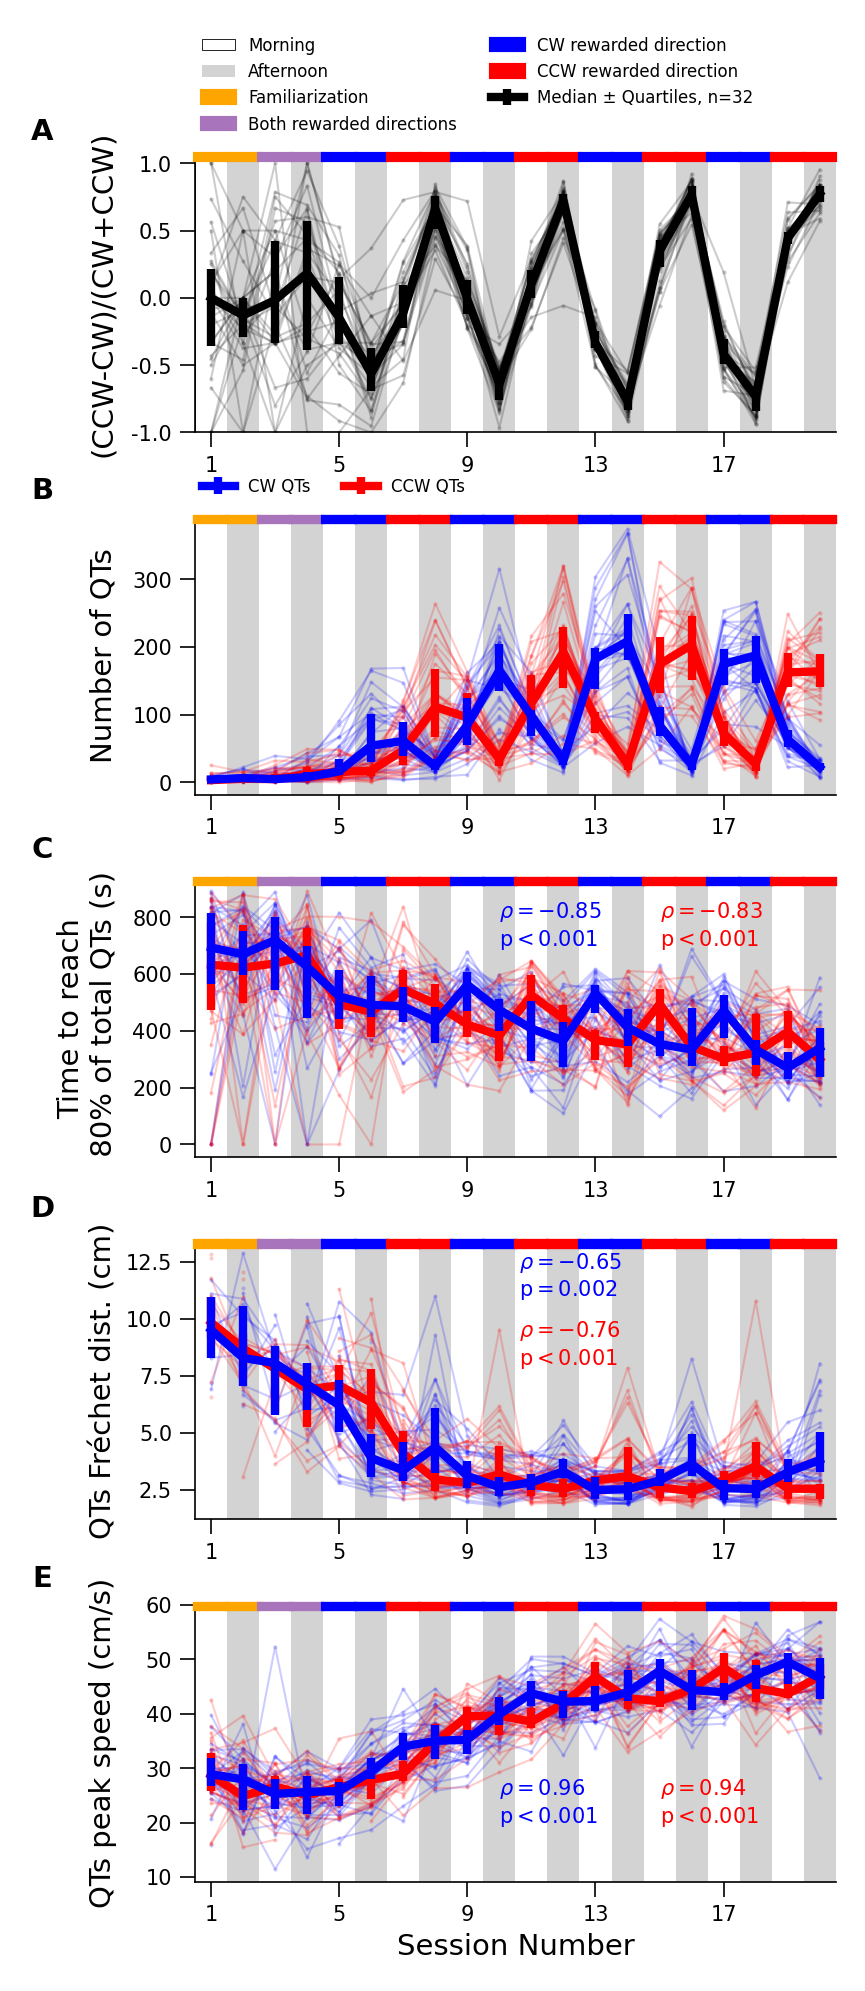

In [21]:
fig=plt.figure(figsize=(cm2inch(7), cm2inch(19)), dpi=300, constrained_layout=False, facecolor='w')
gs = fig.add_gridspec(5, 1 , hspace=0.3)

tick_interval = 4

### Panel A ###
row1 = gs[0].subgridspec(1, 1)

ax_1 = plt.subplot(row1[:])

plot_learning_curve_alt_direction(mouse_ccw_vs_cw_norm_diff_persession, ax_1, xlim=xlim_stats, ylim=[-1,1.07], ylabel='(CCW-CW)/(CW+CCW)', show_xlabel=False,
                                  tick_interval=tick_interval, show_background_legend=True, individual_color='black')

# plot_shuffled_distribution_test_res(ax_1, mouse_ccw_vs_cw_norm_diff_persession, 1000, pulled_interval = False, illustration_mouse_name=None, first_and_last_session_indexes=first_and_last_session_indexes_stats)

fig.text(-0.06, 0.89, 'A', weight='bold', va='center', ha='center', fontsize=7)

### Panel B ###
row2 = gs[1].subgridspec(1, 1)

ax_2 = plt.subplot(row2[:])

plot_learning_curve_alt_direction(mouse_total_cw_persession, ax_2, ylabel='Number of QTs', show_xlabel=False, show_background_legend=False, median_color='blue',
                                  individual_color='blue', main_line_label="CW QTs", tick_interval=tick_interval, xlim=xlim_stats)
plot_learning_curve_alt_direction(mouse_total_ccw_persession, ax_2, ylabel='Number of QTs', show_xlabel=False, show_background_legend=False, median_color='red',
                                  individual_color='red', main_line_label="CCW QTs", tick_interval=tick_interval, xlim=xlim_stats)

fig.text(-0.06, 0.73, 'B', weight='bold', va='center', ha='center', fontsize=7)

### Panel C ###
row3 = gs[2].subgridspec(1, 1)

ax_3 = plt.subplot(row3[:])

plot_learning_curve_alt_direction(mouse_cwturns_threshold_persession, ax_3, ylabel='Time to reach\n 80% of total QTs (s)', show_background_legend=False,
                                  median_color='blue', individual_color='blue', show_xlabel=False, tick_interval=tick_interval, xlim=xlim_stats, show_legend=False)
plot_learning_curve_alt_direction(mouse_ccwturns_threshold_persession, ax_3, ylabel='Time to reach\n 80% of total QTs (s)', show_background_legend=False,
                                  median_color='red', individual_color='red', show_xlabel=False, tick_interval=tick_interval, xlim=xlim_stats, show_legend=False)

plot_shuffled_spearman_test_res(ax_3, (10,700), mouse_cwturns_threshold_persession, 1000,'decreasing', color='blue', first_and_last_session_indexes=first_and_last_session_indexes_stats)    
plot_shuffled_spearman_test_res(ax_3, (15,700), mouse_ccwturns_threshold_persession, 1000,'decreasing', color='red', first_and_last_session_indexes=first_and_last_session_indexes_stats)    

fig.text(-0.06, 0.41, 'D', weight='bold', va='center', ha='center', fontsize=7)

### Panel D ###
row4 = gs[3].subgridspec(1, 1)

ax_4 = plt.subplot(row4[:])

plot_learning_curve_alt_direction(overall_cw_turns_frechet_distances_per_session, ax_4, median_color= 'blue', individual_color='blue', show_xlabel = False, 
                                  xlim=xlim_stats, ylabel='QTs Fréchet dist. (cm)', tick_interval=tick_interval, show_legend=False)
plot_learning_curve_alt_direction(overall_ccw_turns_frechet_distances_per_session, ax_4, median_color= 'red', individual_color='red', show_xlabel = False,
                                  xlim=xlim_stats, ylabel='QTs Fréchet dist. (cm)', tick_interval=tick_interval, show_legend=False)

plot_shuffled_spearman_test_res(ax_4, (10.6,11), overall_cw_turns_frechet_distances_per_session, 1000,'decreasing', color='blue', first_and_last_session_indexes=first_and_last_session_indexes_stats)    
plot_shuffled_spearman_test_res(ax_4, (10.6,8), overall_ccw_turns_frechet_distances_per_session, 1000,'decreasing', color='red', first_and_last_session_indexes=first_and_last_session_indexes_stats)    


fig.text(-0.06, 0.57, 'C', weight='bold', va='center', ha='center', fontsize=7)

### Panel E ###
row5 = gs[4].subgridspec(1, 1)

ax_5 = plt.subplot(row5[:])

plot_learning_curve_alt_direction(mice_median_maximum_cw_turn_speed_persession, ax_5, show_individual_mice=True, median_color= 'blue', individual_color='blue', 
                                  show_xlabel = False, xlim=xlim_stats, ylabel='QTs peak speed (cm/s)', main_line_label="CW QTs", tick_interval=tick_interval,
                                  show_legend=False)
plot_learning_curve_alt_direction(mice_median_maximum_ccw_turn_speed_persession, ax_5, show_individual_mice=True, median_color= 'red', individual_color='red',
                                  show_xlabel = True, xlim=xlim_stats, ylabel='QTs peak speed (cm/s)', main_line_label="CCW QTs", tick_interval=tick_interval,
                                  show_legend=False)

plot_shuffled_spearman_test_res(ax_5, (10,20), mice_median_maximum_cw_turn_speed_persession, 1000,'increasing', color='blue', first_and_last_session_indexes=first_and_last_session_indexes_stats)    
plot_shuffled_spearman_test_res(ax_5, (15,20), mice_median_maximum_ccw_turn_speed_persession, 1000,'increasing', color='red', first_and_last_session_indexes=first_and_last_session_indexes_stats)    


fig.text(-0.06, 0.245, 'E', weight='bold', va='center', ha='center', fontsize=7)

fig.align_ylabels()

fig.tight_layout()

plt.savefig("Figure08.png", facecolor='w', edgecolor='none', bbox_inches='tight', format="png", dpi=300)


In [22]:
# Save the figure as a PDF
fig.savefig("Figure08.pdf", format="pdf", bbox_inches='tight', dpi=300)
